# **Model Training and Evaluation**

In fraud detection, a model that simply guesses "Not Fraud" for every transaction will achieve 99%+ accuracy but catch 0% of the thieves. This is called the Accuracy Paradox.

To fix this, we need to move beyond simple training and use Cost-Sensitive Learning.

In [33]:
# import necessary libraries
from pathlib import Path

# data manipulation libraries
import pandas as pd
import numpy as np

# data preprocessing 
from sklearn.model_selection import train_test_split

# machine learning model
from xgboost import XGBClassifier

# evaluation metrics
from sklearn.metrics import (
    classification_report,
    average_precision_score, 
    precision_recall_curve
)

## Prepare the data

In [34]:
# Load the dataset
file_generator = Path.cwd().parent.rglob("v1.0_fraud_features_ready.csv")
file_path = list(file_generator)[0]
df = pd.read_csv(file_path)

# Separate features and target variable
X = df[[
    #'timestamp', 
    
    # 'user_id', #'device_id',
    
    'amount',  
    
    'lat', 'lon',
    
    #'ip_address', 'is_fraud', 
    
    'hour', 'day_of_week', 
    
    'tx_count_24h', 'avg_spend_user', 
    'amount_ratio', 
    
    'dist_from_last_tx_km', 'travel_velocity_kmph', 
    
    'auth_method_PIN', 'auth_method_Password',
    
    'category_food', 'category_grocery', 
    'category_tech', 'category_travel',
    'category_utilities'
]]

y = df['is_fraud']

## Split the data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)

## Calculate the Scale Weight
- Basically we are calculating the ratio of negative cases to positive cases. 
- This will be used in `scale_pos_weight` parameter of xgboost to tell the algo how much imbalanced the data is.

In [36]:
imbalance_ratio = (len(y_train) - y_train.sum()) / len(y_train)

## Train the model

**The Strategy: XGBoost + scale_pos_weight**

>In 2026, the industry standard for tabular data like this is XGBoost. It has a built-in hyperparameter called `scale_pos_weight` that tells the model: "Paying attention to the 2% of fraud cases is 50x more important than the 98% of legitimate ones."

In [37]:
# Initiate the model with parameter
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
    tree_method="hist",
    eval_metric="aucpr", # We also specify the evaluation metric
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


## Evaluate the model

### Predict probabilities
Q. Why probabilities matters more than predictions?

A. Because of the complicate nature of the real world our model will make mistakes. So making a binary decision based on that is saying like since the probability of fraud for transaction A is 0.4999999 that means it's not fraud, but the probability of fraud for transaction B is 0.5000001 that means it's a fraud. --We can see the ridiculusness of that statement.

Also binary prediction is non-negotiable, you can't intervene in the decision making process.

But with the help of probability, we can set a threshold/decision boundary beyond which we can categorize a transaction is fraud. It also grant us the flexibity of changing this threshold according to our needs.


In [38]:
y_probs = model.predict_proba(X_test)[:,1]

### Business-cost-aware Thresholding 
Q. Why is this necessary?

A. Our model will make mistakes. But not catching a fraud is much more deadly than blocking a legitamite transaction.

But Xgboost treats both of these mistakes equally, if we continue to do so we will loose a lot of money(primary concern for business). So we need a custom cost function that prioritize catching fraud and decide a threshold based on that.

The threshold/decision boundary for the xgboost algo is 0.50, and we know how ridiculus that is. 

In [39]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # project root

from src.threshold_optimization import (
    find_optimal_threshold,
    save_threshold,
)

threshold_info = find_optimal_threshold(
    y_true=y_test.to_numpy(),
    y_prob=y_probs,
    cost_fp=1.0,
    cost_fn=10.0
)

save_threshold(
    threshold_info=threshold_info,
    path=Path.cwd().parent / "artifacts" / "model" / "optimal_threshold.json",
)

PATH = Path.cwd().parent / "artifacts" / "model"

import json

with open(PATH / "optimal_threshold.json") as f:
    best_threshold = json.load(f)["best_threshold"]

### Final Predictions

In [41]:
y_pred_final = (y_probs >= best_threshold).astype(int)

### Evaluation with metrics
We will ignore Accuracy. Instead, we focus on:

- Precision-Recall AUC (PR-AUC): Better than ROC-AUC for imbalanced data.

- Recall: What percentage of actual fraud did we catch?

- F1-Score: The balance between catching fraud and not annoying real customers.

In [42]:
print("Best Threshold:", round(best_threshold, 3))
print("PR-AUC:", round(average_precision_score(y_test, y_probs), 4))
print(classification_report(y_test, y_pred_final))

Best Threshold: 0.84
PR-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1968
           1       1.00      1.00      1.00        32

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### Drift detection
Q. Why is this needed?

A. Change is the only constant. Fraudsters will invent new tricks, and if we stick to the old model, we will get defeated. 

We have to be aware of their change of tactics, and it will show up in the data. This change is called drift(different new data), we have to keep track of this. We track this by looking at the new data, analysing it, and training models with this new data. 

-In conclusion, this is to check for difference in data. Because model perform good on old data but when new data arrives it fails(not all time) to predict things.

In [43]:
# we are going to implement PSI

def population_stability_index(expected, actual, bins=10):
    # 1. Create bins from expected only
    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )
    breakpoints = np.unique(breakpoints)  # avoid duplicate edges

    # 2. Bin both using SAME breakpoints
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts   = np.histogram(actual,   bins=breakpoints)[0]

    # 3. Convert to proportions
    expected_pct = expected_counts / len(expected)
    actual_pct   = actual_counts / len(actual)

    # 4. PSI calculation (with smoothing)
    eps = 1e-6
    psi = np.sum(
        (expected_pct - actual_pct) *
        np.log((expected_pct + eps) / (actual_pct + eps))
    )

    return psi



psi_values = {}

for col in X_train.columns:
    # skip non-numeric columns
    if not np.issubdtype(X_train[col].dtype, np.number):
        continue

    psi_values[col] = population_stability_index(
        X_train[col].values,
        X_test[col].values
    )

df_psi = (
    pd.DataFrame.from_dict(
        psi_values, 
        orient="index", 
        columns=["psi"]
    ).sort_values("psi", ascending=False)
)

df_psi

,psi
hour,0.008645
avg_spend_user,0.006049
day_of_week,0.005820
lat,0.004665
lon,0.004635
dist_from_last_tx_km,0.004282
amount_ratio,0.003056
tx_count_24h,0.002205
amount,0.002100
travel_velocity_kmph,0.000000


# **Model Explainability (SHAP)**
We use SHAP (SHapley Additive ExPlanations) to show exactly which feature triggered the fraud alert.

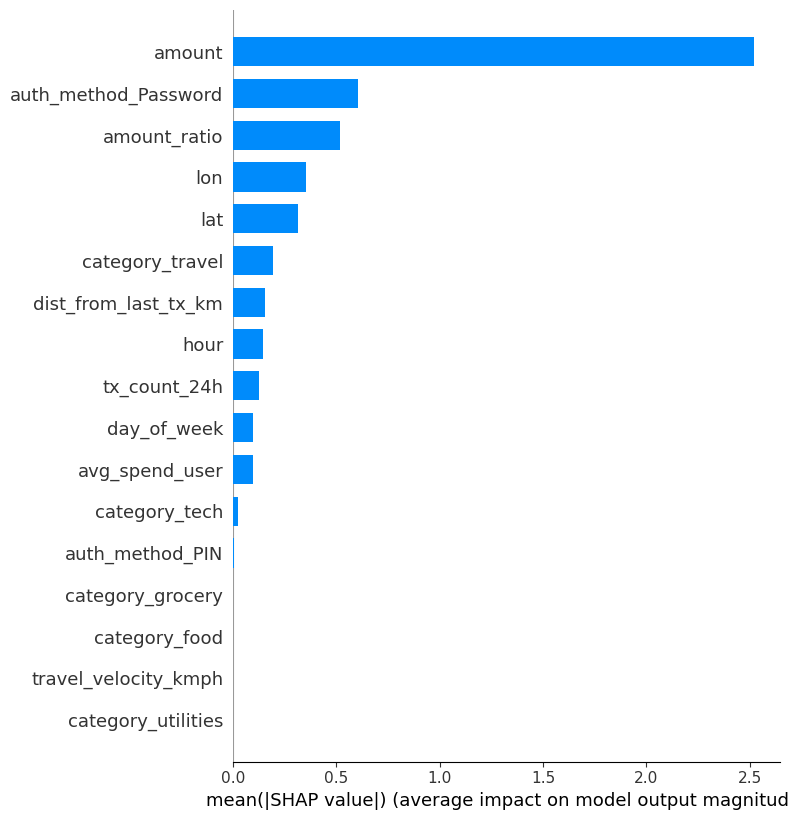

In [44]:
import shap

# Calculate SHAP values for the test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot top features that drive fraud
shap.summary_plot(shap_values, X_test, plot_type="bar")

# **Save the Model**

In [45]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "artifacts" / "model"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [46]:
# Save this in training script
model.save_model(MODEL_DIR / "v1.0_xgb_fraud_detection_model.json")